In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.compose import ColumnTransformer

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("youtube_preupload_engagement_dataset.csv")

df.head()

,video_title,description,log_subscriber_count,upload_hour,upload_day,is_weekend,engagement_rate
0,Facebook Ads Have Changed in 2026! Here’s the ...,Facebook Ads Have Changed in 2026! Here’s the ...,15.255346,13,0,0,8.591549
1,How to Make a Website in Minutes with Canva AI,How to Make a Website in Minutes with Canva AI...,15.255346,13,6,1,5.481887
2,New SEO Trick: Rank Your Website in ChatGPT Se...,New SEO Trick: Rank Your Website in ChatGPT Se...,15.255346,13,5,1,6.753871
3,SEO Game Changer: 6 AI Tools You Need to Know ...,SEO Game Changer: 6 AI Tools You Need to Know ...,15.255346,13,4,0,6.860207
4,How to Become a Data Analyst? | Complete Roadm...,How to Become a Data Analyst? | Complete Roadm...,15.255346,13,3,0,4.792919


In [ ]:
# Cleaning

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_title"] = df["video_title"].apply(clean_text)
df["clean_description"] = df["description"].apply(clean_text)

In [ ]:
# Tokenzation + stopwords removal

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

df["title_tokens"] = df["clean_title"].apply( lambda x: [w for w in x.split() if w not in stop_words])
df["desc_tokens"] = df["clean_description"].apply( lambda x: [w for w in x.split() if w not in stop_words])

In [ ]:
# lemmatization

nltk.download("wordnet")
lemmatizer = WordNetLemmatizer()

df["title_tokens"] = df["title_tokens"].apply( lambda x: [lemmatizer.lemmatize(w) for w in x])

df["desc_tokens"] = df["desc_tokens"].apply( lambda x: [lemmatizer.lemmatize(w) for w in x])

In [ ]:
df["final_title"] = df["title_tokens"].apply(lambda x: " ".join(x))
df["final_description"] = df["desc_tokens"].apply(lambda x: " ".join(x))

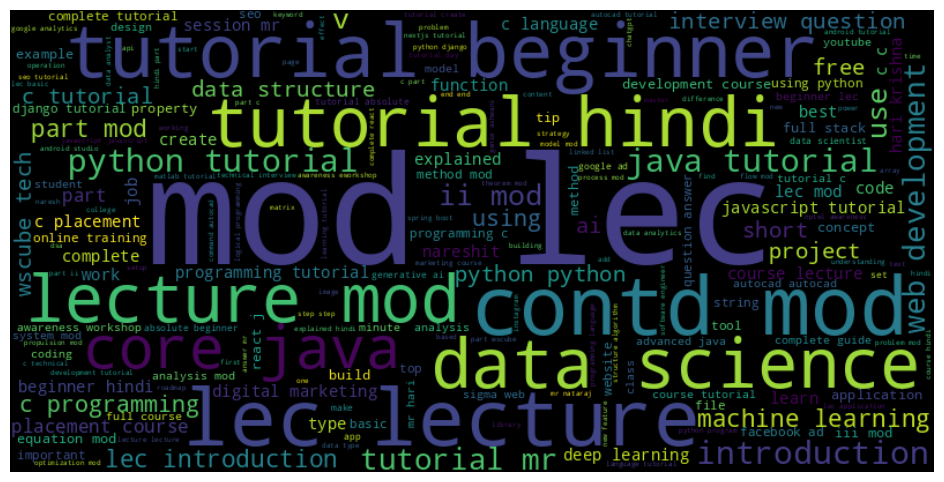

In [ ]:
# Word Cloud (Titles)

text = " ".join(df["final_title"])

wc = WordCloud(width=800, height=400, background_color="black").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

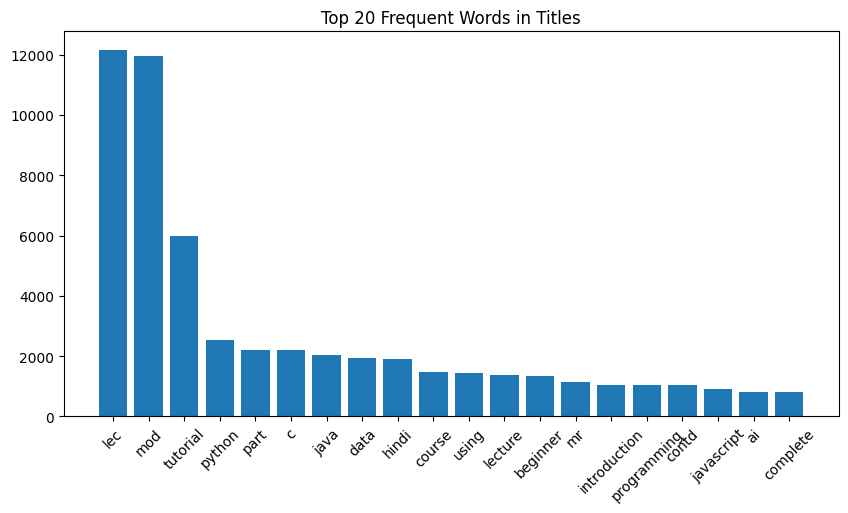

In [ ]:
# Top 20 Frequent Words (Titles)

all_words = " ".join(df["final_title"]).split()
word_freq = Counter(all_words)

top_20 = word_freq.most_common(20)

words, counts = zip(*top_20)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words in Titles")
plt.show()

In [ ]:
# Feature Vectorization (TF-IDF)

df["text_combined"] = df["final_title"] + " " + df["final_description"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, max_df=0.9)
X_text = tfidf.fit_transform(df["text_combined"])

X_numeric = df[["log_subscriber_count", "upload_hour", "upload_day", "is_weekend"]]

In [ ]:
# Combine Text + Numeric Features

X = hstack([X_text, X_numeric.values])
y = df["engagement_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Model Building: Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# 2. Random Forest Regressor

rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# Model Evaluation

def evaluate(y_true, y_pred, model_name):
    print(model_name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression
MAE: 0.6721951169220048
RMSE: 1.3897998081200515
R2: 0.6137194582553949
------------------------------
Random Forest
MAE: 0.684480927109907
RMSE: 1.3160895964016035
R2: 0.6342064523881874
------------------------------


In [ ]:
# Build modeling using a unified pipeline for text and numeric features to ensure training–inference consistency;
# hstack was avoided because it is error-prone in deployment scenarios.

df["text_combined"] = df["final_title"] + " " + df["final_description"]

X = df[["text_combined", "log_subscriber_count", "upload_hour", "upload_day", "is_weekend"]]
y = df["engagement_rate"]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000,ngram_range=(1, 2),min_df=5,max_df=0.9), "text_combined"),

        ("num", "passthrough", ["log_subscriber_count", "upload_hour", "upload_day", "is_weekend"])
    ]
)

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100,max_depth=7,random_state=42,n_jobs=-1))
])

In [ ]:
pipeline.fit(X, y)
joblib.dump(pipeline, "youtube_engagement_pipeline.pkl")

['youtube_engagement_pipeline.pkl']